<a href="https://colab.research.google.com/github/steelpipe75/practice-ml-competition-for-mdxq-2026/blob/main/competition_files/playground/Colab/sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# マナビDXクエスト2026参加者向け練習用機器学習コンペ サンプル ノートブック

## コンペデータ取得

GitHubからリポジトリをcloneしてデータを持ってくる

In [1]:
REPO_URL = "https://github.com/steelpipe75/practice-ml-competition-for-mdxq-2026"
REPO_NAME = "practice-ml-competition-for-mdxq-2026"

In [2]:
!git clone {REPO_URL}

Cloning into 'practice-ml-competition-for-mdxq-2026'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 128 (delta 29), reused 90 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (128/128), 237.11 KiB | 6.77 MiB/s, done.
Resolving deltas: 100% (29/29), done.


## ライブラリをインポート

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as LR
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error as MSE

## コンペ配布データ読み込み

### 学習用データ読み込み

In [4]:
train_df = pd.read_csv(f"./{REPO_NAME}/competition_files/data/train.csv")

In [5]:
train_df

,id,temperature,sunshine_h,humidity,ice_sales
0,1,23.2,6.2,56.5,324
1,2,31.3,5.2,69.0,640
2,3,28.2,3.9,80.6,306
3,4,26.4,6.9,75.6,477
4,5,20.2,6.1,78.2,267
...,...,...,...,...,...
495,496,22.9,2.5,73.4,77
496,497,26.2,7.5,71.7,573
497,498,19.1,2.8,66.2,31
498,499,31.6,7.7,63.3,789


### 評価用データ読み込み

In [6]:
test_df = pd.read_csv(f"./{REPO_NAME}/competition_files/data/test.csv")

In [7]:
test_df

,id,temperature,sunshine_h,humidity
0,501,24.7,3.0,66.0
1,502,28.2,3.0,62.6
2,503,24.6,3.9,61.5
3,504,23.6,3.1,59.9
4,505,24.9,3.4,56.4
...,...,...,...,...
295,796,38.6,10.8,33.2
296,797,39.1,9.9,31.7
297,798,35.9,9.8,30.4
298,799,36.9,10.8,33.3


### サンプル投稿ファイル読み込み

In [8]:
submit = pd.read_csv(f"./{REPO_NAME}/competition_files/data/sample_submission.csv")

In [9]:
submit

,id,ice_sales
0,501,0
1,502,0
2,503,0
3,504,0
4,505,0
...,...,...
295,796,0
296,797,0
297,798,0
298,799,0


## 前処理

### 説明変数、目的変数に分割

In [10]:
X = train_df[["temperature", "sunshine_h", "humidity"]]
y = train_df["ice_sales"]

In [11]:
X

,temperature,sunshine_h,humidity
0,23.2,6.2,56.5
1,31.3,5.2,69.0
2,28.2,3.9,80.6
3,26.4,6.9,75.6
4,20.2,6.1,78.2
...,...,...,...
495,22.9,2.5,73.4
496,26.2,7.5,71.7
497,19.1,2.8,66.2
498,31.6,7.7,63.3


In [12]:
y

,ice_sales
0,324
1,640
2,306
3,477
4,267
...,...
495,77
496,573
497,31
498,789


In [13]:
X_test = test_df[["temperature", "sunshine_h", "humidity"]]

In [14]:
X_test

,temperature,sunshine_h,humidity
0,24.7,3.0,66.0
1,28.2,3.0,62.6
2,24.6,3.9,61.5
3,23.6,3.1,59.9
4,24.9,3.4,56.4
...,...,...,...
295,38.6,10.8,33.2
296,39.1,9.9,31.7
297,35.9,9.8,30.4
298,36.9,10.8,33.3


### 訓練用データ、検証用データに分割

In [15]:
X_train, X_eval, y_train, y_eval = train_test_split(X, y)

In [16]:
X_train

,temperature,sunshine_h,humidity
114,26.9,7.2,70.8
67,29.2,4.6,53.9
242,30.8,6.5,77.0
144,22.0,2.7,59.3
147,25.0,6.1,73.0
...,...,...,...
209,20.3,6.1,84.9
284,26.1,3.1,61.4
5,20.2,3.0,73.1
200,27.0,5.2,76.5


In [17]:
y_train

,ice_sales
114,605
67,479
242,681
144,104
147,409
...,...
209,208
284,255
5,89
200,403


In [18]:
X_eval

,temperature,sunshine_h,humidity
145,18.5,7.3,80.8
121,30.5,3.3,83.4
440,19.2,3.6,83.9
398,28.5,2.1,71.6
88,30.4,2.8,84.7
...,...,...,...
340,24.9,2.1,59.0
282,23.3,3.5,69.6
217,28.5,7.8,73.8
482,24.4,2.6,69.1


In [19]:
y_eval

,ice_sales
145,260
121,375
440,18
398,283
88,343
...,...
340,163
282,169
217,702
482,142


## モデルを訓練

In [20]:
model = LR()

In [21]:
model.fit(X_train, y_train)

LinearRegression()

## 訓練済みモデルによる予測（検証用データ）

In [22]:
y_pred_eval = model.predict(X_eval)

In [23]:
y_pred_eval

array([ 275.02488454,  384.22814186,   16.84754303,  247.03068247,
        341.04696723,  163.53326643,  128.57800327,  292.92745369,
         97.46252345,  567.03387223,  350.23370762,  559.15589961,
         27.09759134,  249.9392692 ,  634.66297914,  561.74515315,
        260.76645322,  360.06877744,  392.61745449,  211.35267102,
        507.17705482,  523.03454232,  266.79559824,   68.41308785,
        303.23990186,   80.94818973,  355.20522763,  373.77271741,
        140.19037875,  311.94976608,  509.64046423,  296.4641235 ,
        656.59953691,  459.42888728,  563.31078992,  304.37216302,
        349.03027375,  624.07278475,  520.74700866,  -36.93471197,
        201.92376026,  160.57706382,  379.05359714,  336.03484358,
        341.84955472,  194.11036494,  354.22780881,  444.2100196 ,
        479.64855807,  438.36256194,  329.22921561,  407.51910209,
          6.01101964,  373.22168625,  445.71723989,  133.25429243,
        322.3933678 ,  575.49910374,  299.9237414 ,  106.21172

予測精度の可視化

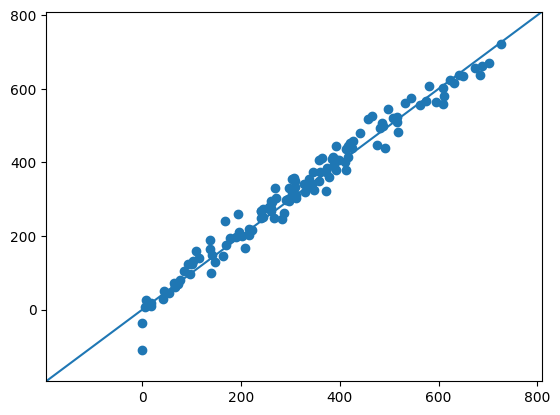

In [24]:
plt.scatter(y_eval, y_pred_eval)

y_eval_min = np.min(y_eval)
y_eval_max = np.max(y_eval)
y_pred_eval_min = np.min(y_pred_eval)
y_pred_eval_max = np.max(y_pred_eval)
y_min = np.minimum(y_eval_min, y_pred_eval_min)
y_max = np.maximum(y_eval_max, y_pred_eval_max)

y_range = y_max - y_min

lim_min = y_min - (y_range * 0.1)
lim_max = y_max + (y_range * 0.1)

plt.xlim([lim_min, lim_max])
plt.ylim([lim_min, lim_max])

plt.plot([lim_min, lim_max], [lim_min, lim_max])

plt.show()

In [25]:
mse_eval = MSE(y_eval, y_pred_eval)
rmse_eval = np.sqrt(mse_eval)

In [26]:
f"{rmse_eval=}"

'rmse_eval=np.float64(29.383706898549946)'

## 訓練済みモデルによる予測（評価用データ）

In [27]:
y_pred_test = model.predict(X_test)

In [28]:
y_pred_test

array([ 193.68067005,  320.29381426,  265.68051582,  174.34283713,
        247.85223359,  426.60607714,  395.81341171,  238.51019201,
        428.05181331,  411.47061846,  336.66000871,  247.73564348,
        102.35664233,  330.80242787,  222.01099151,  396.53833745,
        380.19180183,  487.09400322,  293.59740537,  524.59070778,
        484.62253716,  417.45328065,  332.98787377,  214.40332155,
        391.4387105 ,  260.42595792,  548.17158618,  249.13794343,
        248.70293586,  404.77824911,  353.66510787,  585.78516248,
        388.97693304,  236.2576887 ,  470.62918119,  206.28955667,
        220.80875501,   99.41918606,  198.89044141,  350.27283226,
        291.9303117 ,  443.15685587,  463.94530306,  389.89874369,
        334.50138682,  389.08128686,  352.78263915,  378.22623442,
        270.46257346,  331.68999197,  350.65647889,  386.32861115,
        385.96852136,  413.39643038,  376.22720102,  164.15405564,
        538.57494167,  331.77403184,  357.42851219,  284.03831

## 採点用投稿ファイル作成

In [29]:
submit["ice_sales"] = y_pred_test

In [30]:
submit

,id,ice_sales
0,501,193.680670
1,502,320.293814
2,503,265.680516
3,504,174.342837
4,505,247.852234
...,...,...
295,796,1314.672909
296,797,1267.301814
297,798,1152.045092
298,799,1255.983732


In [31]:
submit.to_csv("submit.csv", index=False)